In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from xgboost import XGBRegressor

drive.mount('/content/drive')

# https://drive.google.com/file/d/14LEG8lm0TbcrmEYeG-RgRvovDuPngmm4/view?usp=sharing
flie_id = "14LEG8lm0TbcrmEYeG-RgRvovDuPngmm4"

url = f"https://drive.google.com/uc?id={flie_id}"
df = pd.read_csv(url)

autos2 = pd.read_csv(url)

df.head()

Mounted at /content/drive


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


In [ ]:
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")


Error cuadrático medio (MSE): 10882624.65
Coeficiente de determinación (R²): 0.91


In [ ]:
# Calcular el RMSE (mas facil de interpretar que el MSE)
rmse = np.sqrt(mse)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Raíz del Error cuadrático medio (RMSE): 3298.88


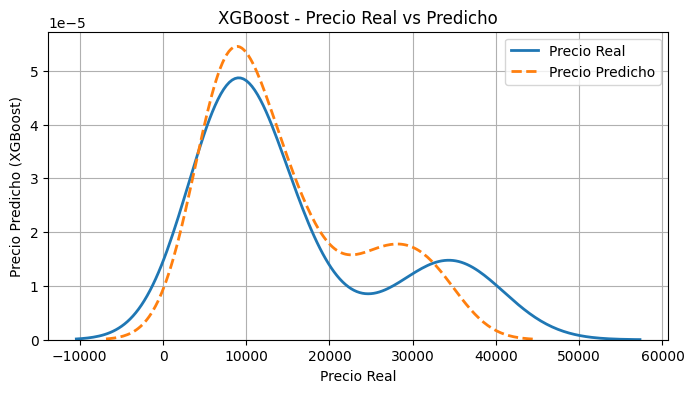

In [ ]:
#plt.scatter(y_test, y_pred, color='darkred')
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho (XGBoost)")
plt.title("XGBoost - Precio Real vs Predicho")
plt.legend()
plt.grid(True)
plt.show()

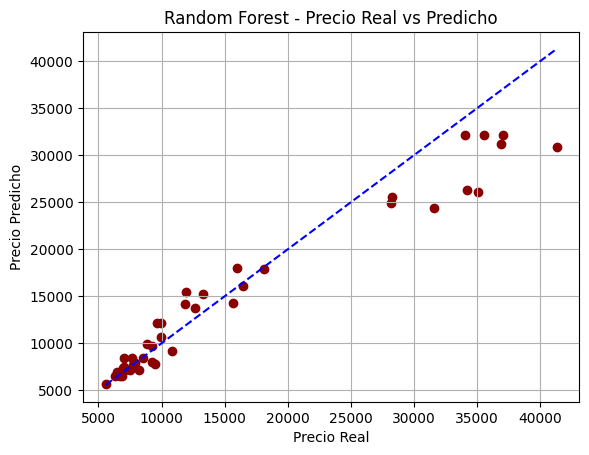

In [ ]:
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') #
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()

In [ ]:
xgb_model2 = XGBRegressor(
n_estimators=300,
learning_rate=0.05,
max_depth=6,
random_state=42
)
xgb_model2.fit(X_train, y_train)
# Evaluar
y_pred = xgb_model2.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# Calcular el RMSE (mas facil de interpretar que el MSE)
rmse = np.sqrt(mse)
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")
print("\n")
plt.figure(figsize=(8, 4))

Error cuadrático medio (MSE): 9242721.95
Coeficiente de determinación (R²): 0.92
Raíz del Error cuadrático medio (RMSE): 3040.18




<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

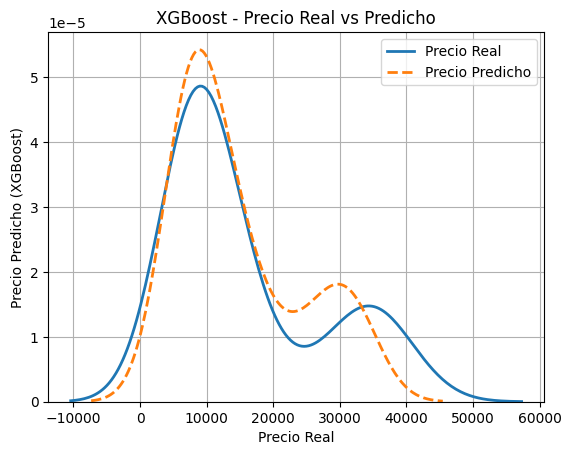

In [ ]:
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho (XGBoost)")
plt.title("XGBoost - Precio Real vs Predicho")
plt.legend()
plt.grid(True)
plt.show()


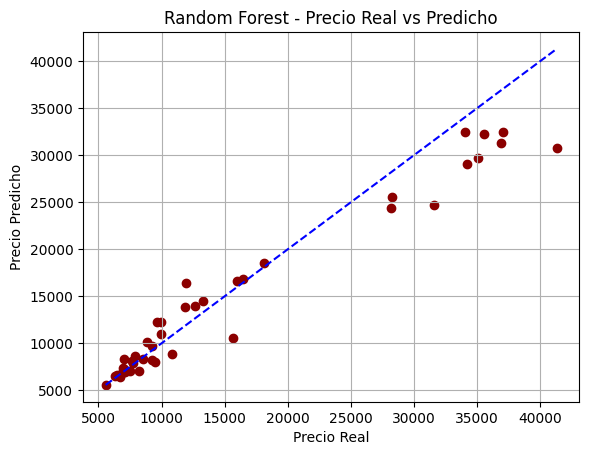

In [ ]:
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') #
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
# Definición del modelo base (usa XGBRegressor, no es necesario pasar parámetro
xgb_base = XGBRegressor(random_state=42, eval_metric='rmse')
# Nota: eval_metric='rmse' se usa para evitar advertencias de XGBoost
# Definición de la rejilla
param_grid = {
'n_estimators': [100, 300, 500],
'learning_rate': [0.01, 0.05, 0.1],
'max_depth': [3, 5, 7],
'min_child_weight': [1, 5, 10],
'subsample': [0.7, 0.9],
'colsample_bytree': [0.7, 0.9]
}
# Inicialización de Grid Search
grid_search_xgb = GridSearchCV(
estimator=xgb_base,
param_grid=param_grid,
scoring='r2',
cv=5, # Es mejor usar cv=5 para más robustez en XGBoost
n_jobs=-1,
verbose=2
)
# Ejecución del ajuste
grid_search_xgb.fit(X_train, y_train)
# Evalúar con:
print("Mejores Parámetros:", grid_search_xgb.best_params_)
best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Mejores Parámetros: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.9}


In [ ]:
# 1. Crear el modelo final con los parámetros óptimos
best_xgb_model = XGBRegressor(
colsample_bytree=0.7,
learning_rate=0.05,
max_depth=7,
min_child_weight=1,
n_estimators=300,
subsample=0.9,
random_state=42,
eval_metric='rmse'
)
# 2. Entrenar el modelo final
best_xgb_model.fit(X_train, y_train)
# 3. Evaluar
y_pred = best_xgb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# Calcular el RMSE (mas facil de interpretar que el MSE)
rmse = np.sqrt(mse)
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R²): {r2:.2f}")
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")
print("\n")
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho (XGBoost)")
plt.title("XGBoost - Precio Real vs Predicho")
plt.legend()
plt.grid(True)
plt.show()

SyntaxError: invalid character '²' (U+00B2) (2638738948.py, line 22)

In [ ]:
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') #
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Random Forest - Precio Real vs Predicho")
plt.grid(True)
plt.show()